# First Light · PyTorch

My first end-to-end neural-network experiment for **CSC 5991: AI for Augmented and Virtual Reality**.

I started with a single clothing image, learned how a model updates its weights, trained a classifier, and then explored validation-based model selection. The baseline achieved **82.37% test accuracy**; the final extension is evaluated at the end.

**How to use this notebook:** select the project’s `.venv` Python kernel and run cells from top to bottom. The saved outputs document my completed session. Training cells change model weights; a fresh kernel and a full run give a coherent new experiment, whose numbers may differ. The extension uses `trial_model` so it does not replace the baseline.

**Learning context:** I wrote and ran the initial exercise with AI mentoring. The final explanations, presentation cleanup, and result-summary cells were refined with Codex.

## 1. Check my Python environment

I checked that the notebook uses my project’s `.venv` and that PyTorch and Torchvision import successfully. Apple GPU availability is reported here; the device is selected later. The notebook and README belong in the project folder, while `.venv` holds installed packages.

In [4]:
import sys
import torch
import torchvision

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Apple GPU available:", torch.backends.mps.is_available())

Python: /Users/fahad/Downloads/To keep/2026/09 Sep/AR_VR/assignmemt_1/first-light-pytorch/.venv/bin/python
PyTorch: 2.14.0
Torchvision: 0.29.0
Apple GPU available: True


## 2. Explore one clothing image

I chose Fashion-MNIST: 28 × 28 grayscale images in 10 clothing categories. This is classification: the input is an image and the target is a category. A dataset index chooses an example; it is different from the example’s class label. Index 9 in this run is a sandal, label 5. Resizing here only enlarges the preview.

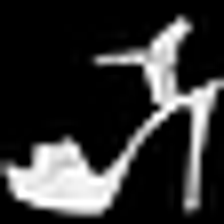

Label number: 5
Category: Sandal


In [7]:
from torchvision.datasets import FashionMNIST

training_data = FashionMNIST(
    root="data",
    train=True,
    download=True

)

image, label = training_data[9]

display(image.resize((224, 224)))
print("Label number:", label)
print("Category:", training_data.classes[label])

## 3. Turn pixels into numbers

`ToTensor()` converts this image to a float tensor with shape `[channels, height, width] = [1, 28, 28]` and scales its original byte-valued pixels to 0–1. The model learns from these numbers.

In [8]:
from torchvision.transforms import ToTensor

to_tensor = ToTensor()
pixels = to_tensor(image)

print("Shape:", pixels.shape)
print("Data type:", pixels.dtype)
print("Lowest brightness:", pixels.min().item())
print("Highest brightness:", pixels.max().item())

Shape: torch.Size([1, 28, 28])
Data type: torch.float32
Lowest brightness: 0.0
Highest brightness: 1.0


## 4. Build my first neural network

Flattening produces 28 × 28 = **784 inputs**. The hidden layer has **32 neurons**, a design choice; ReLU adds nonlinearity. The output has **10 scores**, one per clothing category, regardless of the hidden-layer width. `unsqueeze(0)` adds a batch dimension. These raw scores are called logits, not probabilities.

In [9]:
from torch import nn

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 32),
    nn.ReLU(),
    nn.Linear(32, 10)
)

scores = model(pixels.unsqueeze(0))

print("Output shape:", scores.shape)
print("Scores:", scores)

Output shape: torch.Size([1, 10])
Scores: tensor([[ 0.0705,  0.0571, -0.1318,  0.1692,  0.1237, -0.0038,  0.1324,  0.2291,
         -0.0316,  0.0041]], grad_fn=<AddmmBackward0>)


## 5. Predict a label and measure the error

`argmax(dim=1)` selects the category with the highest score. My untrained model predicted Sneaker for a Sandal. Cross-entropy compares all 10 logits with the correct integer label (`torch.long`). I pass logits directly to this loss, without applying softmax first. Loss measures prediction error; it is not an accuracy percentage.

In [10]:
predicted_label = scores.argmax(dim=1).item()

print("Predicted:", training_data.classes[predicted_label])
print("Actual:", training_data.classes[label])

loss_fn = nn.CrossEntropyLoss()
target = torch.tensor([label], dtype=torch.long)
loss = loss_fn(scores, target)

print("Loss:", loss.item())

Predicted: Sneaker
Actual: Sandal
Loss: 2.3733835220336914


## 6. Learn from one example

One update follows **clear gradients → forward pass → loss → backward pass → optimizer step**. `backward()` computes gradients; `step()` changes weights. With SGD and learning rate 0.01, this example’s loss fell from 2.3734 to 2.2520. This demonstrates learning on one image, not generalization. `no_grad()` disables gradient recording when checking the result.

In [ ]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

optimizer.zero_grad()

before_scores = model(pixels.unsqueeze(0))
before_loss = loss_fn(before_scores, target)

# calculate gradients
before_loss.backward()
# update the model's parameters
optimizer.step()

with torch.no_grad():
    after_scores = model(pixels.unsqueeze(0))
    after_loss = loss_fn(after_scores, target)

print("Loss before:", before_loss.item())
print("Loss after:", after_loss.item())

Loss before: 2.3733835220336914
Loss after: 2.2519853115081787


## 7. Prepare training and test data

I load 60,000 training images and 10,000 separate test images, now with tensor conversion built in. The original baseline trains on all 60,000 training images. Test examples are used for evaluation and never for gradient updates.

In [15]:
from torch.utils.data import DataLoader

train_dataset = FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_dataset = FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

## 8. Group examples into batches

Each full batch contains 64 images with shape `[64, 1, 28, 28]` and 64 labels. Training shuffles examples; testing keeps a fixed order. The final batch can be smaller than 64.

In [16]:
train_loader = DataLoader(
    train_dataset, batch_size=64, shuffle=True
)

test_loader = DataLoader(
    test_dataset, batch_size=64, shuffle=False
)

images, labels = next(iter(train_loader))

print("Images:", images.shape)
print("Labels:", labels.shape)

Images: torch.Size([64, 1, 28, 28])
Labels: torch.Size([64])


## 9. Choose the compute device

I use Apple’s MPS backend when available and otherwise use the CPU. Model parameters and input tensors must be on the same device. I create the optimizer after moving the model. This continues the model from the one-image exercise.

In [17]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
model = model.to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
print("Training on:", device)

Training on: mps


## 10. Train for three epochs

An epoch is one complete pass through the training dataset. For each batch I compute loss and update weights. I multiply each batch’s mean loss by its actual size, sum, and divide by the number of images. The saved epoch losses are **1.1799 → 0.6811 → 0.5822**. Falling training loss alone does not establish performance on unseen images.

In [19]:
loss_history = []

for epoch in range(3):
    model.train()
    total_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        batch_scores = model(images)
        batch_loss = loss_fn(batch_scores, labels)

        # Compute gradients of this batch loss. 
        batch_loss.backward()
        # Use those gradients to update the weights.
        optimizer.step()

        total_loss += batch_loss.item() * images.size(0)

    epoch_loss = total_loss / len(train_dataset)
    loss_history.append(epoch_loss)
    print(f"Epoch {epoch + 1}: loss = {epoch_loss:.4f}")

Epoch 1: loss = 1.1799
Epoch 2: loss = 0.6811
Epoch 3: loss = 0.5822


## 11. Evaluate the three-epoch baseline

`model.eval()` selects evaluation behavior; `torch.no_grad()` separately disables gradient recording. I count correct predictions across all 10,000 test images. This run achieved **79.41%**. Evaluation performs forward passes but no weight updates.

In [21]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        scores = model(images)
        predictions = scores.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

test_accuracy = (correct/total)*100
print(f"Test accuracy: {test_accuracy:.2f}%")

Test accuracy: 79.41%


## 12. Inspect sample predictions

I display the first nine test images with predicted and actual labels. Green means correct; red means incorrect. A nine-image gallery is illustrative, not a substitute for full-test accuracy. This earlier gallery is overwritten on disk by the six-epoch gallery below.

Matplotlib is building the font cache; this may take a moment.


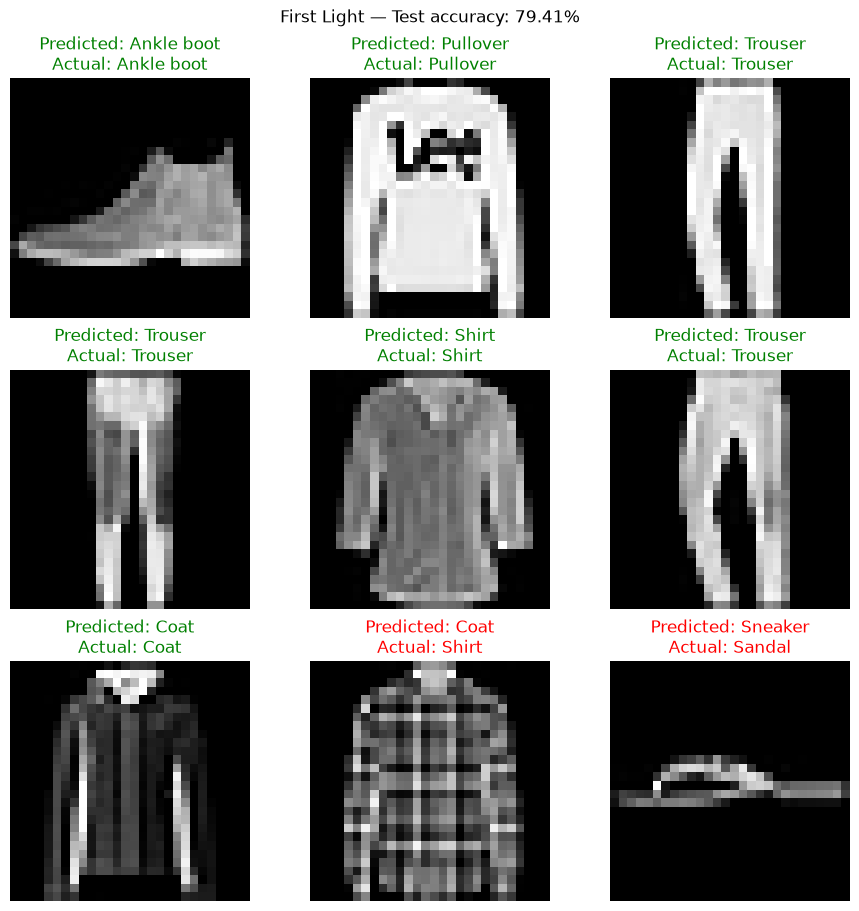

In [22]:
import matplotlib.pyplot as plt

images, labels = next(iter(test_loader))

model.eval()
with torch.no_grad():
    predictions = model(images.to(device)).argmax(dim=1).cpu()

fig, axes = plt.subplots(
    3, 3, figsize=(9, 9), layout="constrained"
)

for i, ax in enumerate(axes.flat):
    predicted_id = predictions[i].item()
    actual_id = labels[i].item()

    predicted_name = test_dataset.classes[predicted_id]
    actual_name = test_dataset.classes[actual_id]
    color = "green" if predicted_id == actual_id else "red"

    ax.imshow(images[i].squeeze(0), cmap="gray", vmin=0, vmax=1)
    ax.set_title(
        f"Predicted: {predicted_name}\nActual: {actual_name}",
        color=color
    )
    ax.axis("off")

fig.suptitle(f"First Light — Test accuracy: {test_accuracy:.2f}%")
fig.savefig("prediction_gallery.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Continue to six epochs

I continue training the same model for epochs 4–6, preserving learned weights and `loss_history`. The additional losses are **0.5336 → 0.5041 → 0.4844**. Rerunning this cell trains the model further; its printed epoch numbers do not automatically track extra reruns.

In [23]:
for epoch in range(3, 6):
    model.train()
    total_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        batch_scores = model(images)
        batch_loss = loss_fn(batch_scores, labels)

        # Compute gradients of this batch loss. 
        batch_loss.backward()
        # Use those gradients to update the weights.
        optimizer.step()

        total_loss += batch_loss.item() * images.size(0)

    epoch_loss = total_loss / len(train_dataset)
    loss_history.append(epoch_loss)
    print(f"Epoch {epoch + 1}: loss = {epoch_loss:.4f}")

Epoch 4: loss = 0.5336
Epoch 5: loss = 0.5041
Epoch 6: loss = 0.4844


## 14. Measure the six-epoch result

Full-test accuracy improved to **82.37%**, up **2.96 percentage points** from 79.41%. I looked at test results during learning, so this is an exploratory comparison. In a controlled experiment, validation guides choices and the test set is reserved for final reporting.

In [24]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        scores = model(images)
        predictions = scores.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

test_accuracy = (correct/total)*100
print(f"Test accuracy: {test_accuracy:.2f}%")

Test accuracy: 82.37%


## 15. Save my final baseline gallery

All nine displayed predictions were correct in this saved run. Overall test accuracy remains **82.37%**, not 100%. The saved `prediction_gallery.png` is the image embedded in my README.

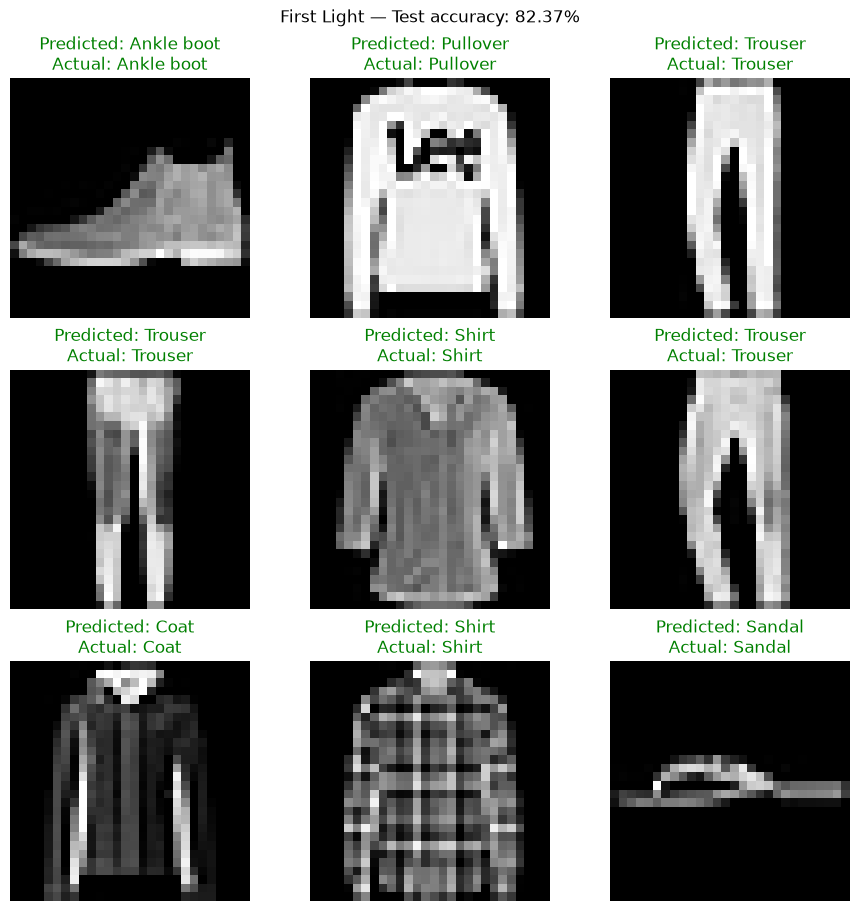

In [25]:
import matplotlib.pyplot as plt

images, labels = next(iter(test_loader))

model.eval()
with torch.no_grad():
    predictions = model(images.to(device)).argmax(dim=1).cpu()

fig, axes = plt.subplots(
    3, 3, figsize=(9, 9), layout="constrained"
)

for i, ax in enumerate(axes.flat):
    predicted_id = predictions[i].item()
    actual_id = labels[i].item()

    predicted_name = test_dataset.classes[predicted_id]
    actual_name = test_dataset.classes[actual_id]
    color = "green" if predicted_id == actual_id else "red"

    ax.imshow(images[i].squeeze(0), cmap="gray", vmin=0, vmax=1)
    ax.set_title(
        f"Predicted: {predicted_name}\nActual: {actual_name}",
        color=color
    )
    ax.axis("off")

fig.suptitle(f"First Light — Test accuracy: {test_accuracy:.2f}%")
fig.savefig("prediction_gallery.png", dpi=150, bbox_inches="tight")
plt.show()

## 16. Make a validation split

For the optimization extension, I split the original training set into **48,000 fitting images** and **12,000 validation images**. The 10,000 test images remain separate. A seed makes the split repeatable. The original model already saw all 60,000 images, so I must train a fresh model for this validation split.

In [32]:
from torch.utils.data import random_split

fit_data, val_data = random_split(
    train_dataset,
    [48000, 12000],
    generator=torch.Generator().manual_seed(42)
)

## 17. Start a separate optimization experiment

`trial_model` starts with fresh weights and leaves my baseline model intact. I keep the same 784 → 32 → 10 architecture, SGD, learning rate 0.01, and batch size 64. This explores training duration and validation-based selection, not a larger network. A seed improves repeatability but does not guarantee identical results across devices or library versions.

In [33]:
fit_loader = DataLoader(fit_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)

torch.manual_seed(42)

trial_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 32),
    nn.ReLU(),
    nn.Linear(32, 10)
).to(device)

trial_optimizer = torch.optim.SGD(trial_model.parameters(), lr=0.01)

## 18. Turn the loops into reusable functions

`train_one_epoch` updates weights and returns average training loss. `evaluate_loss` measures average loss without updates. Both divide by `len(loader.dataset)`, so the denominator matches the fitting or validation split. Defining a function does not execute its body; its cell must run before the function is called.

In [34]:
def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0.0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        scores = model(images)
        loss = loss_fn(scores, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

    return total_loss / len(loader.dataset)


def evaluate_loss(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            scores = model(images)
            loss = loss_fn(scores, labels)

            total_loss += loss.item() * images.size(0)

    return total_loss / len(loader.dataset)

## 19. Select weights using validation loss

I allow at most **30 epochs** and use **patience = 5**: five consecutive epochs without a new lowest validation loss trigger a stop. `deepcopy` saves an independent snapshot of the best weights, which I restore afterward. **In my saved run, early stopping did not trigger: training reached the 30-epoch cap, and epoch 30 was best.** Training loss was **0.3903** and validation loss was **0.4139**. This does not prove convergence or that more training cannot help. `trial_history` records values for the plot below.

In [35]:
from copy import deepcopy

best_loss = float("inf")
best_weights = deepcopy(trial_model.state_dict())
best_epoch = 0
epochs_without_improvement = 0
patience = 5
trial_history = []

for epoch in range(30):
    train_loss = train_one_epoch(
        trial_model, fit_loader, trial_optimizer, loss_fn, device
    )

    val_loss = evaluate_loss(
        trial_model, val_loader, loss_fn, device
    )

    trial_history.append({"epoch": epoch + 1, "train_loss": train_loss, "val_loss": val_loss})

    print(
        f"Epoch {epoch + 1:02d} | "
        f"Training loss: {train_loss:.4f} | "
        f"Validation loss: {val_loss:.4f}"
    )

    if val_loss < best_loss:
        best_loss = val_loss
        best_weights = deepcopy(trial_model.state_dict())
        best_epoch = epoch + 1
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print("Stopping: validation loss hasn't improved for 5 epochs.")
        break

trial_model.load_state_dict(best_weights)
trial_model.eval()

print(f"Restored epoch {best_epoch}, validation loss: {best_loss:.4f}")

Epoch 01 | Training loss: 1.2884 | Validation loss: 0.8534
Epoch 02 | Training loss: 0.7455 | Validation loss: 0.6868
Epoch 03 | Training loss: 0.6351 | Validation loss: 0.6137
Epoch 04 | Training loss: 0.5785 | Validation loss: 0.5676
Epoch 05 | Training loss: 0.5421 | Validation loss: 0.5385
Epoch 06 | Training loss: 0.5170 | Validation loss: 0.5207
Epoch 07 | Training loss: 0.4989 | Validation loss: 0.5045
Epoch 08 | Training loss: 0.4846 | Validation loss: 0.4937
Epoch 09 | Training loss: 0.4733 | Validation loss: 0.4881
Epoch 10 | Training loss: 0.4637 | Validation loss: 0.4737
Epoch 11 | Training loss: 0.4563 | Validation loss: 0.4738
Epoch 12 | Training loss: 0.4496 | Validation loss: 0.4741
Epoch 13 | Training loss: 0.4435 | Validation loss: 0.4655
Epoch 14 | Training loss: 0.4385 | Validation loss: 0.4534
Epoch 15 | Training loss: 0.4341 | Validation loss: 0.4510
Epoch 16 | Training loss: 0.4299 | Validation loss: 0.4462
Epoch 17 | Training loss: 0.4263 | Validation loss: 0.44

## 20. Compare training and validation curves

Both losses generally decreased in the completed run. Validation loss fluctuated but reached its lowest recorded value at epoch 30. There is no clear sustained validation deterioration in these 30 epochs; this is not proof that overfitting is impossible.

The displayed curve was reconstructed from the 30 saved log lines, rounded to four decimals, without retraining. On a fresh full run, the training cell records full-precision values in `trial_history` automatically.

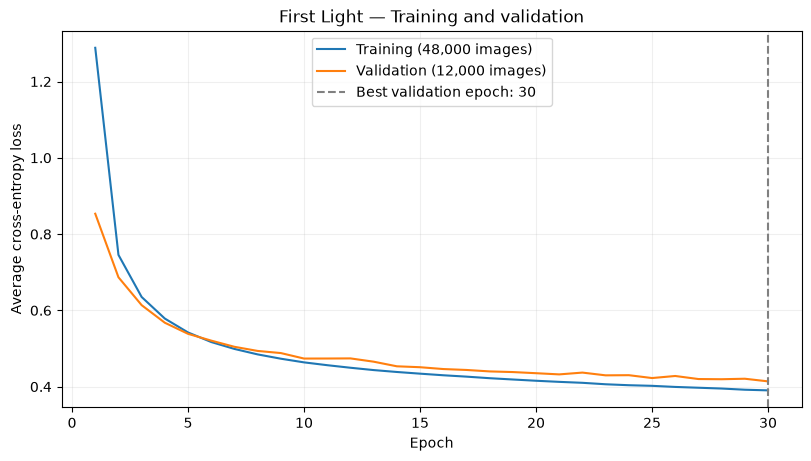

In [ ]:
import matplotlib.pyplot as plt

# The training loop records one entry per epoch in trial_history.
epochs = [row["epoch"] for row in trial_history]
fig, ax = plt.subplots(figsize=(8, 4.5), layout="constrained")
ax.plot(epochs, [row["train_loss"] for row in trial_history], label="Training (48,000 images)")
ax.plot(epochs, [row["val_loss"] for row in trial_history], label="Validation (12,000 images)")
ax.axvline(best_epoch, color="gray", linestyle="--", label=f"Best validation epoch: {best_epoch}")
ax.set(xlabel="Epoch", ylabel="Average cross-entropy loss", title="First Light — Training and validation")
ax.legend()
ax.grid(alpha=0.2)
fig.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()


## 21. Report the restored model’s test performance

This final evaluation uses the weights selected by validation loss and makes no training updates. I compare against the six-epoch baseline, but the experiments have different training-set sizes and initializations, so this does not isolate the effect of early stopping. The test set was already viewed in the baseline exercise; these are exploratory results, not a completely untouched final benchmark.

In [ ]:
# Evaluate the restored trial model without changing any weights.
trial_model.eval()
trial_correct = 0
trial_total = 0
trial_total_loss = 0.0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        trial_scores = trial_model(images)
        trial_total_loss += loss_fn(trial_scores, labels).item() * labels.size(0)
        trial_correct += (trial_scores.argmax(dim=1) == labels).sum().item()
        trial_total += labels.size(0)

trial_test_accuracy = 100 * trial_correct / trial_total
trial_test_loss = trial_total_loss / trial_total
accuracy_change = trial_test_accuracy - test_accuracy
print(f"Baseline, 6 epochs: {test_accuracy:.2f}% test accuracy")
print(f"Validation-selected model, epoch {best_epoch}: {trial_test_accuracy:.2f}% test accuracy")
print(f"Correct test predictions: {trial_correct:,}/{trial_total:,}")
print(f"Change from baseline: {accuracy_change:+.2f} percentage points")
print(f"Trial test loss: {trial_test_loss:.4f}")
print(f"Best validation loss: {best_loss:.4f}")


Baseline, 6 epochs: 82.37% test accuracy
Validation-selected model, epoch 30: 84.50% test accuracy
Correct test predictions: 8,450/10,000
Change from baseline: +2.13 percentage points
Trial test loss: 0.4347
Best validation loss: 0.4139


## What I take away

- My baseline improved from **79.41%** to **82.37%** when I continued from three to six epochs.
- The validation-selected model achieved **84.50% test accuracy**, a change of **+2.13 percentage points** from the six-epoch baseline.
- Epoch **30** had the best validation loss (**0.4139**). The run ended at its epoch limit, not because patience ran out.
- Training loss tells me about fitting; validation helps choose when to stop; test accuracy describes performance on the test examples.
- A good stopping decision balances validation improvement, time, and the task’s needs. It does not certify a global optimum or promise 99.9% accuracy.
- The connection to my future AR/VR work is the training process: tensors, differentiable models, losses, optimization, and evaluation. This clothing classifier is a foundation, not a 3D reconstruction system.